In [3]:
# 02_train_compare.ipynb — первая ячейка (импорты)
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score
import time
import matplotlib.pyplot as plt
from tqdm import tqdm  # добавь в начало ячейки с импортами

DATA_PATH = r"../data/raw/ogyeiv2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("❌ CUDA не найден. GPU нет или не установлен драйвер.")

PyTorch version: 2.7.1+cu118
CUDA available: True
GPU name: NVIDIA GeForce RTX 4060


In [5]:
# Вторая ячейка — Dataset (читает картинки и первый параметр из txt)
class PillDataset(Dataset):
    def __init__(self, data_path, split='train', transform=None):
        self.images_dir = f"{data_path}/{split}/images"
        self.labels_dir = f"{data_path}/{split}/labels"
        self.files = [f for f in os.listdir(self.labels_dir) if f.endswith('.txt')]
        self.transform = transform
        
        # Загружаем названия классов для вывода
        df_names = pd.read_csv(f"{data_path}/extracted_sentences.csv", header=None)
        self.id_to_name = dict(zip(range(len(df_names)), df_names[0].tolist()))
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        txt_file = self.files[idx]
        # БЕРЁМ ТОЛЬКО ПЕРВОЕ ЧИСЛО ИЗ TXT
        with open(f"{self.labels_dir}/{txt_file}", 'r') as f:
            class_id = int(float(f.read().strip().split()[0]))
        
        img_file = txt_file.replace('.txt', '.jpg')
        image = Image.open(f"{self.images_dir}/{img_file}").convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, class_id, self.id_to_name.get(class_id, f"class_{class_id}")

In [6]:
# Третья ячейка — трансформации
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка данных
train_dataset = PillDataset(DATA_PATH, 'train', train_transform)
val_dataset = PillDataset(DATA_PATH, 'valid', val_transform)
test_dataset = PillDataset(DATA_PATH, 'test', val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Number of classes: {len(set([train_dataset.id_to_name[k] for k in train_dataset.id_to_name]))}")

Train: 3136 images, Val: 672, Test: 672
Number of classes: 112


In [7]:
# ============================================
# 4. СОЗДАНИЕ DATALOADER (с pin_memory)
# ============================================
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 3136 images, Val: 672, Test: 672


In [8]:

# ============================================
# 5. ПРОВЕРКА GPU
# ============================================
print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 4060


In [9]:
# ============================================
# ФУНКЦИЯ ОБУЧЕНИЯ (30 ЭПОХ)
# ============================================
def train_simple(model, model_name, num_epochs=30):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
    
    best_val_acc = 0
    
    for epoch in range(num_epochs):
        print(f"\n--- {model_name} Epoch {epoch+1}/{num_epochs} ---")
        
        # ОБУЧЕНИЕ
        model.train()
        train_loss = 0
        for i, (images, labels, _) in enumerate(train_loader):
            images = images.cuda(non_blocking=True)
            labels = labels.cuda(non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
            if i % 30 == 0:
                print(f"  Batch {i}, Loss: {loss.item():.4f}")
        
        avg_train_loss = train_loss / len(train_loader)
        print(f"  Средний Train Loss: {avg_train_loss:.4f}")
        
        # ВАЛИДАЦИЯ
        model.eval()
        correct = 0
        total = 0
        val_loss = 0
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images = images.cuda(non_blocking=True)
                labels = labels.cuda(non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        print(f"  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Сохраняем лучшую модель
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"../artifacts/models/{model_name}_best.pt")
            print(f"  ✅ Сохранена лучшая модель с accuracy: {val_acc:.4f}")
        
        # Уменьшаем LR при плато
        scheduler.step(val_acc)
    
    return best_val_acc

In [12]:
# ============================================
# 7. СОЗДАНИЕ МОДЕЛЕЙ
# ============================================
models_dict = {
    'ResNet50': models.resnet50(pretrained=True),
    'EfficientNet_B0': models.efficientnet_b0(pretrained=True),
    'MobileNet_V3': models.mobilenet_v3_large(pretrained=True)
}

# Замена последних слоёв
models_dict['ResNet50'].fc = nn.Linear(2048, 112)
models_dict['EfficientNet_B0'].classifier[1] = nn.Linear(1280, 112)
models_dict['MobileNet_V3'].classifier[3] = nn.Linear(1280, 112)

# Перенос на GPU
for name in models_dict:
    models_dict[name] = models_dict[name].cuda()

# ОБУЧЕНИЕ (30 эпох)
results = {}
for name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"Обучение {name} (30 эпох)")
    print(f"{'='*60}")
    best_acc = train_simple(model, name, num_epochs=30)
    results[name] = best_acc

# Финальные результаты
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ (30 эпох)")
print("="*60)
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")


Обучение ResNet50 (30 эпох)

--- ResNet50 Epoch 1/30 ---
  Batch 0, Loss: 4.7632
  Batch 30, Loss: 4.2030
  Batch 60, Loss: 2.9905
  Batch 90, Loss: 2.1722
  Средний Train Loss: 3.4752
  Val Loss: 2.1183, Val Acc: 0.5357
  ✅ Сохранена лучшая модель с accuracy: 0.5357

--- ResNet50 Epoch 2/30 ---
  Batch 0, Loss: 1.9174
  Batch 30, Loss: 1.2612
  Batch 60, Loss: 1.1924
  Batch 90, Loss: 0.6298
  Средний Train Loss: 1.2655
  Val Loss: 0.6715, Val Acc: 0.8631
  ✅ Сохранена лучшая модель с accuracy: 0.8631

--- ResNet50 Epoch 3/30 ---
  Batch 0, Loss: 0.7480
  Batch 30, Loss: 0.5632
  Batch 60, Loss: 0.4863
  Batch 90, Loss: 0.3360
  Средний Train Loss: 0.4877
  Val Loss: 0.8850, Val Acc: 0.7961

--- ResNet50 Epoch 4/30 ---
  Batch 0, Loss: 0.2827
  Batch 30, Loss: 0.3200
  Batch 60, Loss: 0.1881
  Batch 90, Loss: 0.1318
  Средний Train Loss: 0.2112
  Val Loss: 1.1610, Val Acc: 0.6771

--- ResNet50 Epoch 5/30 ---
  Batch 0, Loss: 0.1494
  Batch 30, Loss: 0.0551
  Batch 60, Loss: 0.0816
  

In [13]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

In [14]:
# ============================================
# 8. ТЕСТИРОВАНИЕ НА TEST SET
# ============================================
def test_model(model, model_name, model_path):
    """Финальное тестирование на test set"""
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.cuda(non_blocking=True)
            labels = labels.cuda(non_blocking=True)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    print(f"\n📊 {model_name} - Test Results:")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  Weighted F1: {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    
    return {'accuracy': test_acc, 'f1': f1, 'precision': precision, 'recall': recall}


In [15]:
# ============================================
# 9. ТЕСТИРОВАНИЕ НА TEST SET
# ============================================
print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ НА TEST SET")
print("="*60)

test_results = {}
for name, model in models_dict.items():
    model_path = f"../artifacts/models/{name}_best.pt"
    if os.path.exists(model_path):
        test_results[name] = test_model(model, name, model_path)
    else:
        print(f"⚠️ Модель {name} не найдена: {model_path}")


ТЕСТИРОВАНИЕ НА TEST SET

📊 ResNet50 - Test Results:
  Accuracy: 0.9985
  Weighted F1: 0.9985
  Precision: 0.9987
  Recall: 0.9985

📊 EfficientNet_B0 - Test Results:
  Accuracy: 0.9955
  Weighted F1: 0.9956
  Precision: 0.9965
  Recall: 0.9955

📊 MobileNet_V3 - Test Results:
  Accuracy: 0.9851
  Weighted F1: 0.9842
  Precision: 0.9891
  Recall: 0.9851


In [16]:
# ============================================
# ПАРСИНГ HISTORY ИЗ ФАЙЛА С ВЫВОДОМ ОБУЧЕНИЯ
# ============================================

import re

# Читаем файл с выводом обучения
with open('02_train_compare_learning.ipynb', 'r', encoding='utf-8') as f:
    content = f.read()

# Регулярные выражения для извлечения данных
val_acc_pattern = r'Val Acc: ([\d\.]+)'
train_loss_pattern = r'Средний Train Loss: ([\d\.]+)'
val_loss_pattern = r'Val Loss: ([\d\.]+)'

# Разбиваем на блоки по моделям
models = ['ResNet50', 'EfficientNet_B0', 'MobileNet_V3']

training_history = {}

for model in models:
    # Находим блок для текущей модели
    model_start = content.find(f'Обучение {model}')
    if model_start == -1:
        continue
    
    # Находим следующий блок или конец
    next_model_start = len(content)
    for other in models:
        if other != model:
            pos = content.find(f'Обучение {other}', model_start + len(model))
            if pos != -1 and pos < next_model_start:
                next_model_start = pos
    
    model_content = content[model_start:next_model_start]
    
    # Извлекаем значения
    val_accs = re.findall(val_acc_pattern, model_content)
    train_losses = re.findall(train_loss_pattern, model_content)
    val_losses = re.findall(val_loss_pattern, model_content)
    
    # Преобразуем в числа с плавающей точкой
    val_accs = [float(x) for x in val_accs]
    train_losses = [float(x) for x in train_losses]
    val_losses = [float(x) for x in val_losses]
    
    training_history[model] = {
        'val_acc': val_accs,
        'train_loss': train_losses,
        'val_loss': val_losses
    }
    
    print(f"{model}: {len(val_accs)} эпох из 30")

# Проверяем, что извлекли
print(f"\n✅ Извлечено {len(training_history)} моделей")
for model in training_history:
    print(f"  {model}: {len(training_history[model]['val_acc'])} эпох")

ResNet50: 30 эпох из 30
EfficientNet_B0: 30 эпох из 30
MobileNet_V3: 30 эпох из 30

✅ Извлечено 3 моделей
  ResNet50: 30 эпох
  EfficientNet_B0: 30 эпох
  MobileNet_V3: 30 эпох


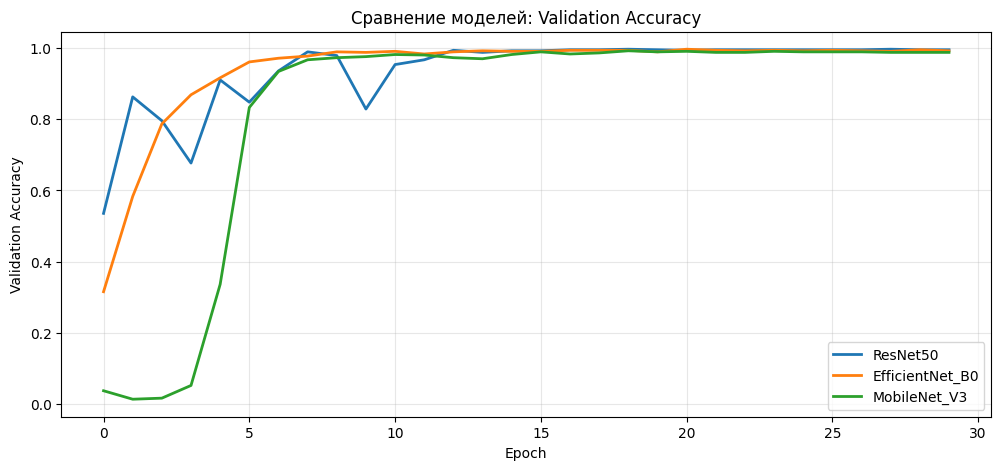

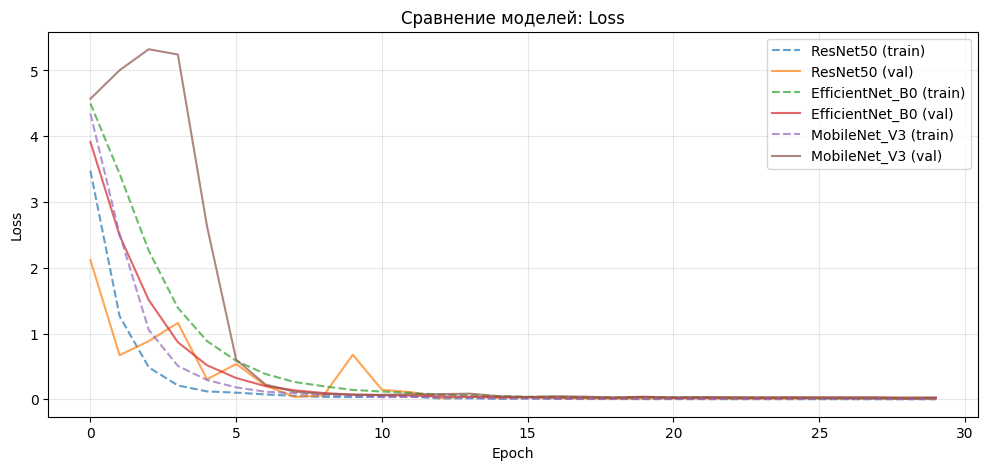

In [17]:
# ============================================
# 10. СРАВНИТЕЛЬНЫЕ ГРАФИКИ
# ============================================
os.makedirs("../artifacts/figures", exist_ok=True)

# График Validation Accuracy
plt.figure(figsize=(12, 5))
for name, history in training_history.items():
    plt.plot(history['val_acc'], label=name, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Сравнение моделей: Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../artifacts/figures/val_accuracy_comparison.png', dpi=150)
plt.show()

# График Loss
plt.figure(figsize=(12, 5))
for name, history in training_history.items():
    plt.plot(history['train_loss'], label=f"{name} (train)", linestyle='--', alpha=0.7)
    plt.plot(history['val_loss'], label=f"{name} (val)", alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Сравнение моделей: Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../artifacts/figures/loss_comparison.png', dpi=150)
plt.show()

In [19]:
# ============================================
# 10. ИТОГОВАЯ ТАБЛИЦА 
# ============================================
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*60)

# Собираем данные вручную из того, что есть
summary = []
for name in results:
    # results[name] — это число (best_val_acc)
    best_val_acc = results[name]
    
    # test_results[name] — это словарь или None
    test_acc = test_results.get(name, {}).get('accuracy', 0) if test_results.get(name) else 0
    test_f1 = test_results.get(name, {}).get('f1', 0) if test_results.get(name) else 0
    
    # Время (если нет — ставим прочерк)
    time_min = '-'
    
    row = {
        'Model': name,
        'Best Val Acc': f"{best_val_acc:.4f}",
        'Test Acc': f"{test_acc:.4f}",
        'Test F1': f"{test_f1:.4f}",
        'Time (min)': time_min
    }
    summary.append(row)

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

# Сохраняем таблицу
os.makedirs("../artifacts/metrics", exist_ok=True)
summary_df.to_csv('../artifacts/metrics/final_comparison.csv', index=False)
print("\n✅ Результаты сохранены в artifacts/metrics/final_comparison.csv")


ИТОГОВЫЕ РЕЗУЛЬТАТЫ
          Model Best Val Acc Test Acc Test F1 Time (min)
       ResNet50       0.9970   0.9985  0.9985          -
EfficientNet_B0       0.9970   0.9955  0.9956          -
   MobileNet_V3       0.9926   0.9851  0.9842          -

✅ Результаты сохранены в artifacts/metrics/final_comparison.csv



🏆 Лучшая модель: ResNet50


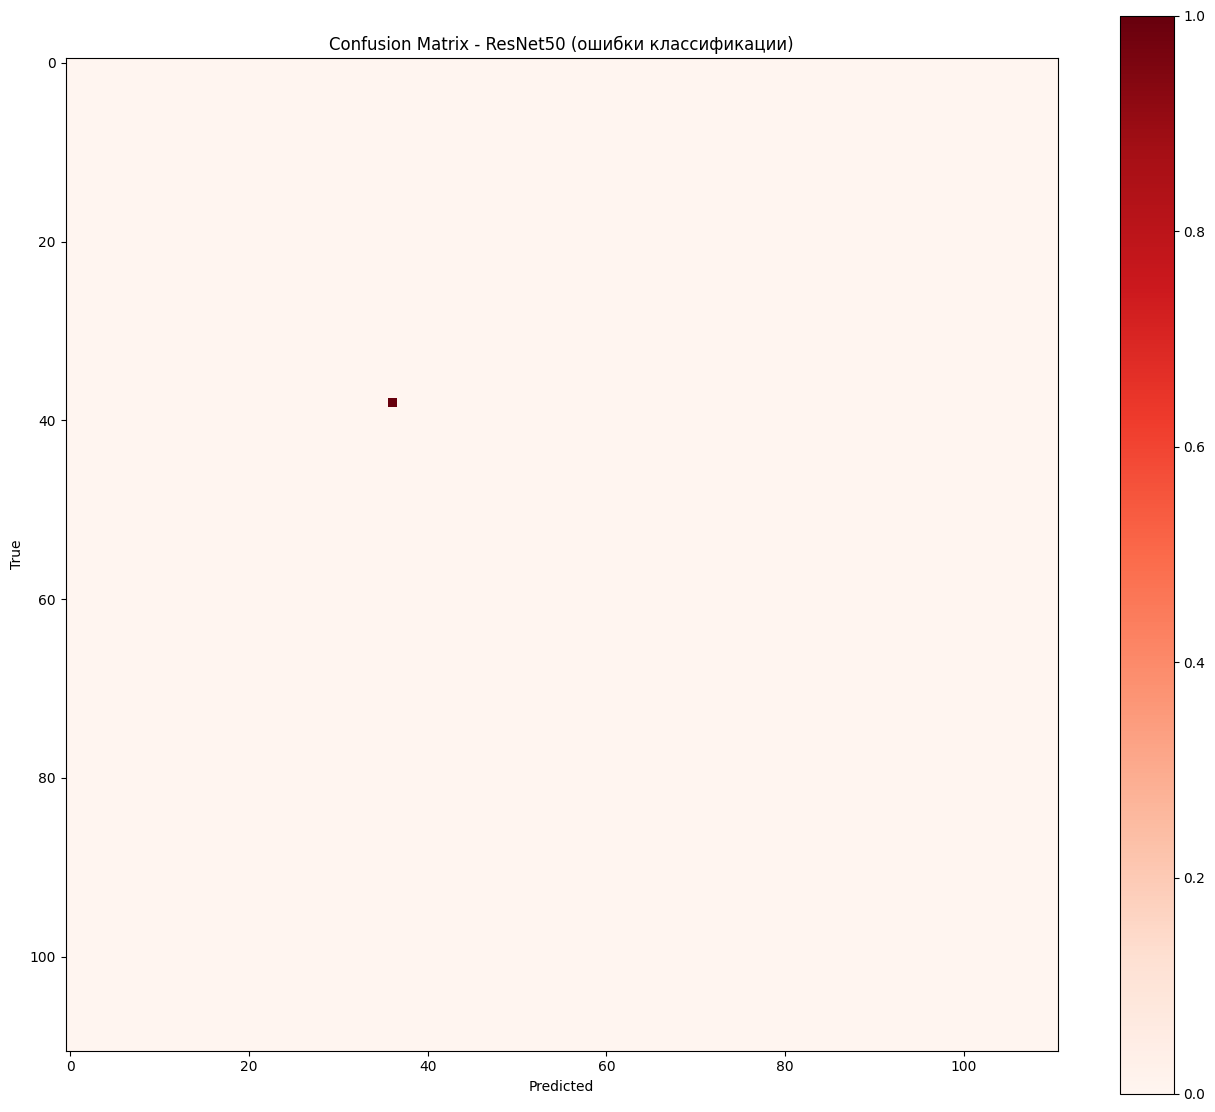


✅ ЭКСПЕРИМЕНТ ЗАВЕРШЁН


In [20]:
# ============================================
# 11. CONFUSION MATRIX ДЛЯ ЛУЧШЕЙ МОДЕЛИ
# ============================================
# Находим лучшую модель по Test Acc
best_model_name = max(test_results.items(), key=lambda x: x[1]['accuracy'])[0]
print(f"\n🏆 Лучшая модель: {best_model_name}")

# Строим confusion matrix для лучшей модели
model = models_dict[best_model_name]
model.load_state_dict(torch.load(f"../artifacts/models/{best_model_name}_best.pt"))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.cuda()
        labels = labels.cuda()
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix (уменьшенная для отображения)
plt.figure(figsize=(16, 14))
cm = confusion_matrix(all_labels, all_preds)
# Показываем только где есть ошибки (для наглядности)
cm_display = cm.copy()
# Маскируем диагональ для лучшего вида ошибок
np.fill_diagonal(cm_display, 0)

plt.imshow(cm_display, cmap='Reds', interpolation='nearest')
plt.colorbar()
plt.title(f'Confusion Matrix - {best_model_name} (ошибки классификации)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('../artifacts/figures/confusion_matrix_best.png', dpi=150)
plt.show()

print("\n" + "="*60)
print("✅ ЭКСПЕРИМЕНТ ЗАВЕРШЁН")
print("="*60)